# 🏢 EMPLOYEE PERFORMANCE ANALYSIS PROJECT

- Name: Aniket Jain
- Domain: Human Resources Analytics
- Project Type: Multi-class Classification
- Submission: As per IABAC Guidelines
- 
# 🎯 PROJECT OBJECTIVES

## Task 1: Department-wise Performance Analysis
- Analyze employee performance across departments
- Identify underperforming departments
- Detect patterns contributing to low ratings

## Task 2: Identify Top 3 Key Factors Affecting Performance
- Perform feature correlation analysis
- Use model-based feature importance
- Interpret results in business context

## Task 3: Predictive Model Development
- Build machine learning classification models
- Compare multiple algorithms
- Select best-performing model

## Task 4: Business Recommendations
- Provide actionable insights
- Recommend strategies to improve performance

# 📊 DATASET INFORMATION

- File Used: INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls
- Target Variable: PerformanceRating
- Problem Type: Multi-class Classification
- Objective: Predict employee performance and identify performance drivers

# 🛠️ METHODOLOGY EXPLANATION

Data Preprocessing:
- Checked and handled missing values.
- Treated outliers in experience-related features using IQR-based capping.
- Encoded categorical variables for modeling.
- Split dataset into training and testing sets.

Feature Engineering:
- Analyzed correlations among numerical features.
- Removed highly correlated variables to reduce redundancy.
- Evaluated feature importance using tree-based models.

Modeling:
- Built Logistic Regression as baseline model.
- Trained Decision Tree for non-linear relationships.
- Used Random Forest to improve generalization and accuracy.

Evaluation:
- Used Accuracy, Precision, Recall, F1-score, and Confusion Matrix.
- Compared models and selected best-p

# 📌 OUTCOME

- Clear identification of factors affecting employee performance
- Department-wise performance insights
- A trained predictive model
- Strategic recommendations for management

### 📌 EXECUTIVE SUMMARY

INX Future Inc. observed a decline in employee performance and increasing service delivery concerns.
This project analyzes employee data to identify key performance drivers and build a predictive model
to classify employees into Low (2), Average (3), and High (4) performance categories.

After data cleaning, feature engineering, and model comparison,
Random Forest achieved the highest accuracy (91%) and demonstrated strong class separation.

The analysis identified experience, promotion gap, job satisfaction,
environment satisfaction, and training frequency as major factors influencing performance.

The findings provide management with data-driven insights to improve employee morale,
optimize training programs, and reduce performance-related risks.

## Import Required Libraries


In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier


pandas is used for data handling Numpy is used for numerical calculation Matplotlib ans seaborn are used for data visualization

In [143]:
data = pd.read_excel(r"C:\Users\Administrator\Documents\Datamites CDS\IABAC\INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls")

## Basic Checks

In [144]:
data

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9,3,4,8,7,7,7,No,3


In [145]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [146]:
data.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [147]:
data.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

In [148]:
data.tail()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9,3,4,8,7,7,7,No,3
1199,E100998,24,Female,Life Sciences,Single,Sales,Sales Executive,Travel_Rarely,3,2,...,1,4,3,3,2,2,2,0,Yes,2


In [149]:
data.isnull().sum()

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

In [150]:
data.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


In [151]:
data.shape

(1200, 28)

The dataset contains 1200 rows and 28 columns. This shows that the dataset is very Small

In [152]:
num = data.select_dtypes(include=['int64', 'float64'])

In [153]:
len(num.columns)

19

In [154]:
len(data.columns)

28

In [155]:
cat = data.select_dtypes(include='object')
len(cat.columns)

9

In [156]:
data.dtypes.value_counts()

int64     19
object     9
Name: count, dtype: int64


The dataset conatains two types of feature -

19 Numerical features with integer values and 9 Categorical features of object type.

In [157]:
count = data.EmpDepartment.value_counts()
count

EmpDepartment
Sales                     373
Development               361
Research & Development    343
Human Resources            54
Finance                    49
Data Science               20
Name: count, dtype: int64

In [158]:
data.PerformanceRating.value_counts()

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

In [159]:
data['PerformanceRating'].value_counts(normalize=True)*100

PerformanceRating
3    72.833333
2    16.166667
4    11.000000
Name: proportion, dtype: float64

Almost 73 out of 100 people have rating 3 ,

16 out of 100 people have rating 2

11 out of 100 people have rating 4

In [160]:
data.duplicated().sum()

np.int64(0)

There is no Duplicate vaues in data

In [161]:
for col in data.select_dtypes(include='object').columns:
    print('->', col, data[col].unique(),'\n')


-> EmpNumber ['E1001000' 'E1001006' 'E1001007' ... 'E100994' 'E100995' 'E100998'] 

-> Gender ['Male' 'Female'] 

-> EducationBackground ['Marketing' 'Life Sciences' 'Human Resources' 'Medical' 'Other'
 'Technical Degree'] 

-> MaritalStatus ['Single' 'Married' 'Divorced'] 

-> EmpDepartment ['Sales' 'Human Resources' 'Development' 'Data Science'
 'Research & Development' 'Finance'] 

-> EmpJobRole ['Sales Executive' 'Manager' 'Developer' 'Sales Representative'
 'Human Resources' 'Senior Developer' 'Data Scientist'
 'Senior Manager R&D' 'Laboratory Technician' 'Manufacturing Director'
 'Research Scientist' 'Healthcare Representative' 'Research Director'
 'Manager R&D' 'Finance Manager' 'Technical Architect' 'Business Analyst'
 'Technical Lead' 'Delivery Manager'] 

-> BusinessTravelFrequency ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel'] 

-> OverTime ['No' 'Yes'] 

-> Attrition ['No' 'Yes'] 



All the unique values in the Feature having data type 'object'

In [162]:
(data == "unknown").sum().sort_values()

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

# 🔍 Exploratory Data Analysis (EDA)

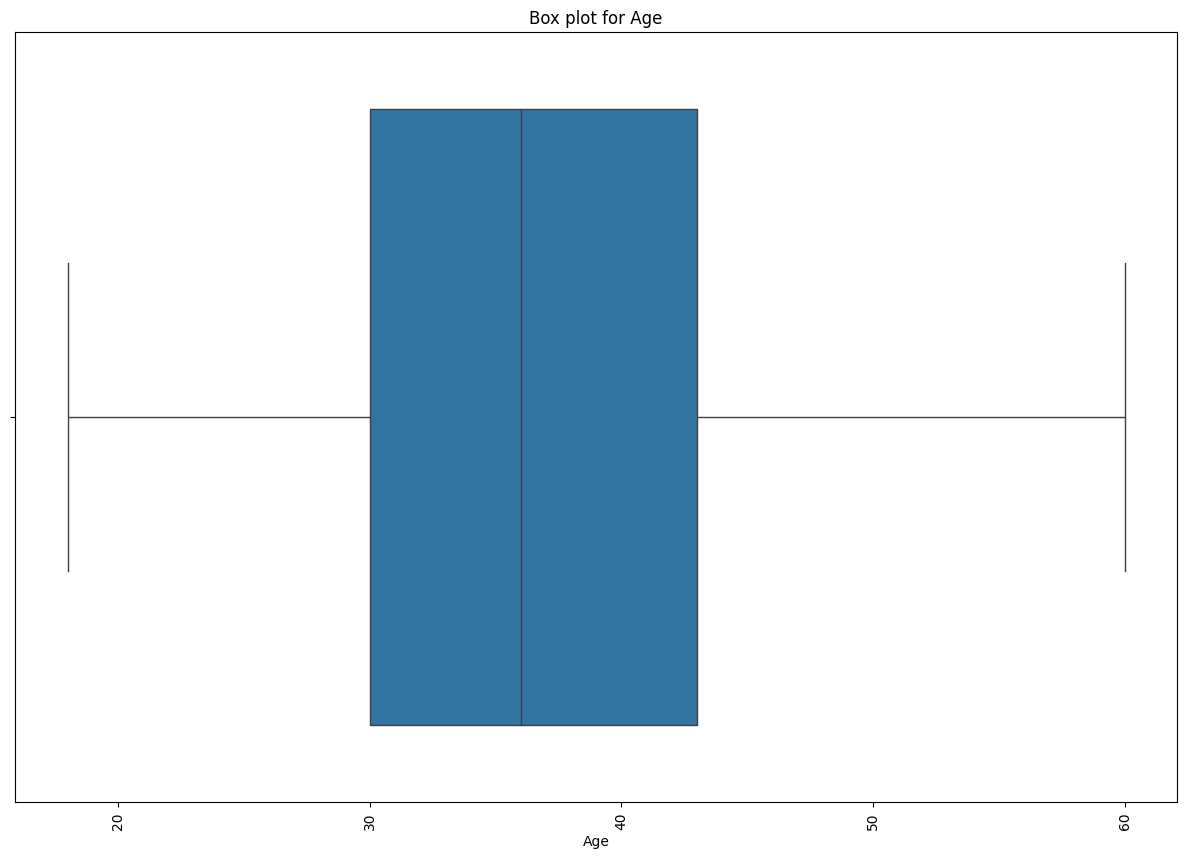

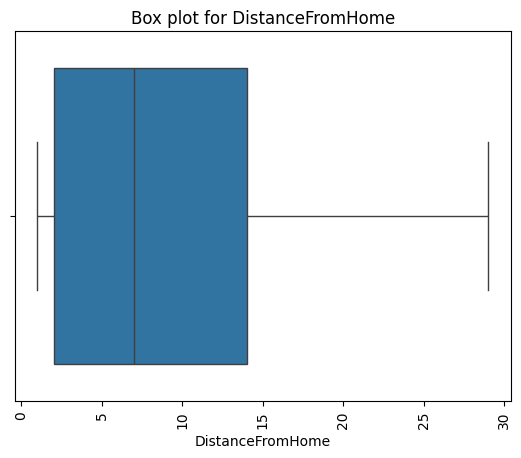

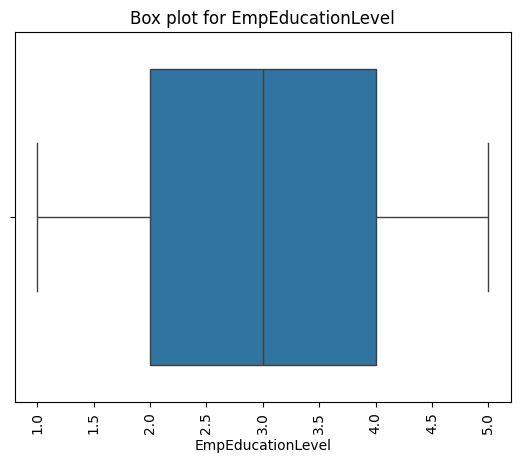

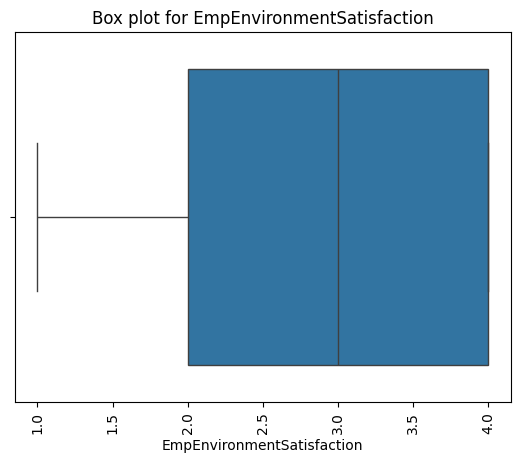

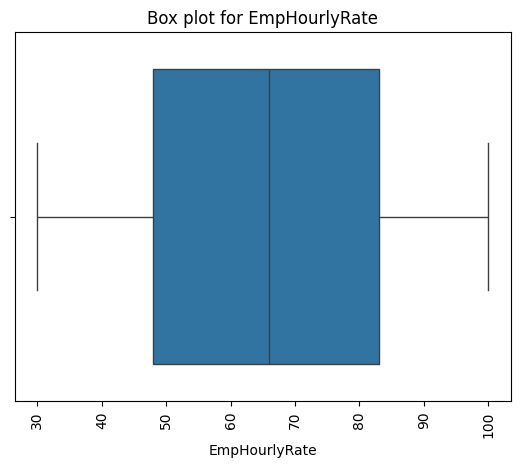

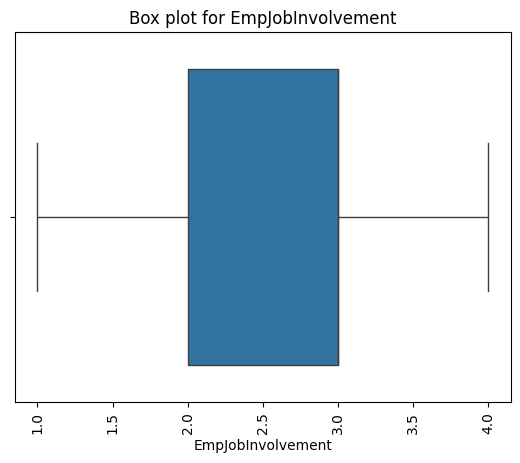

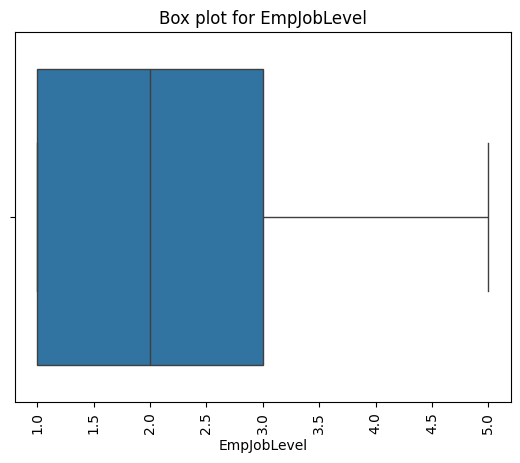

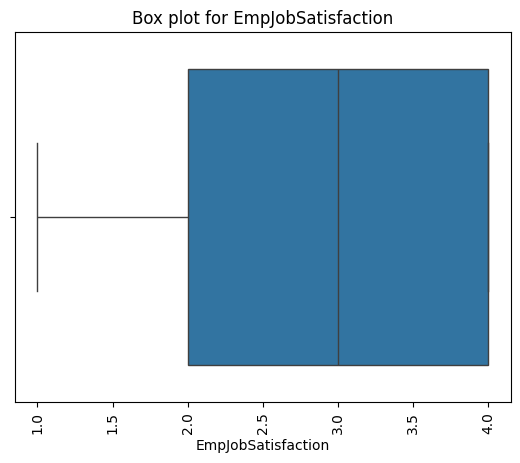

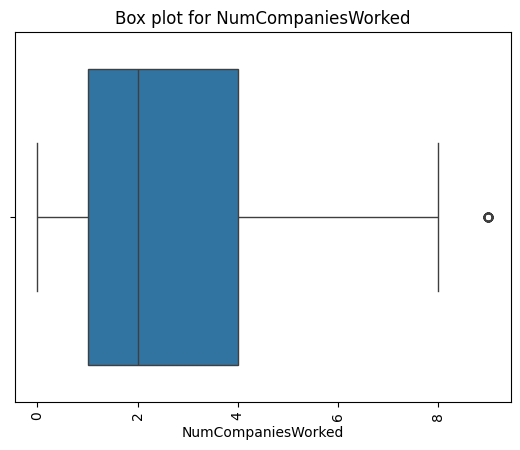

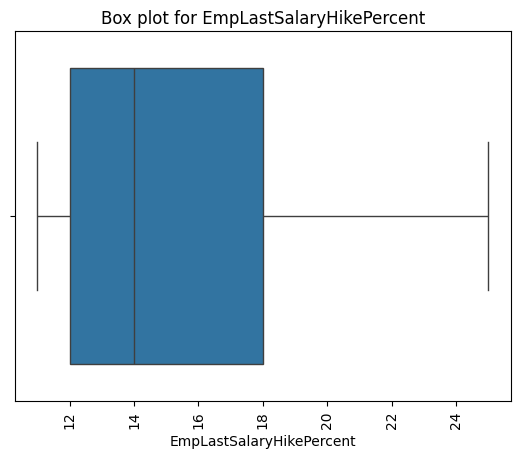

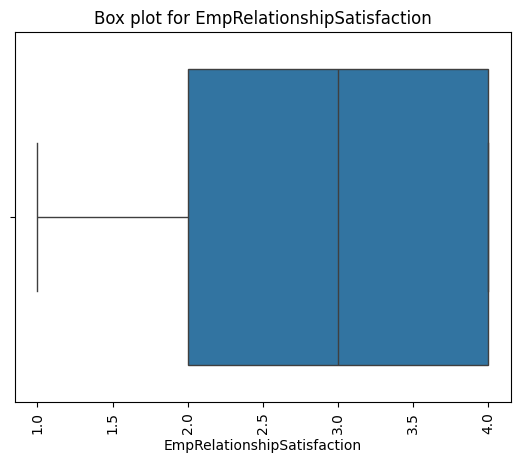

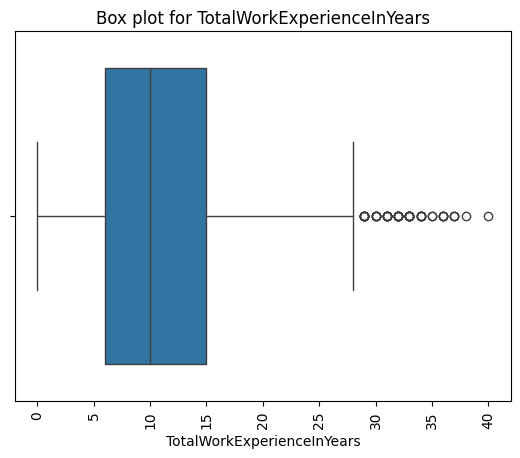

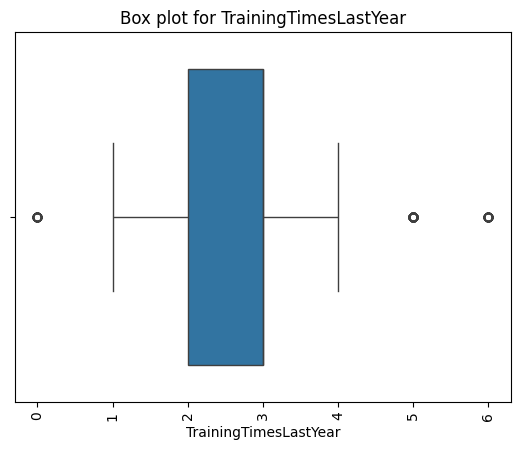

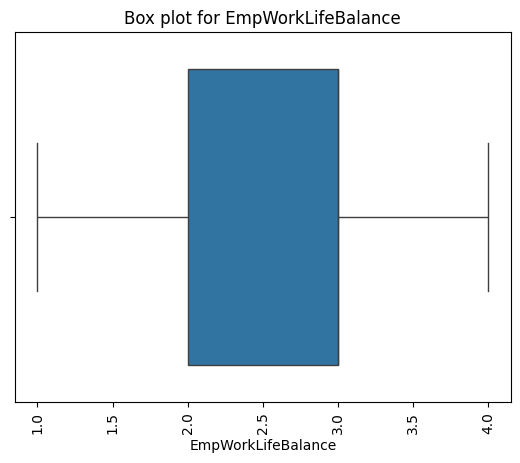

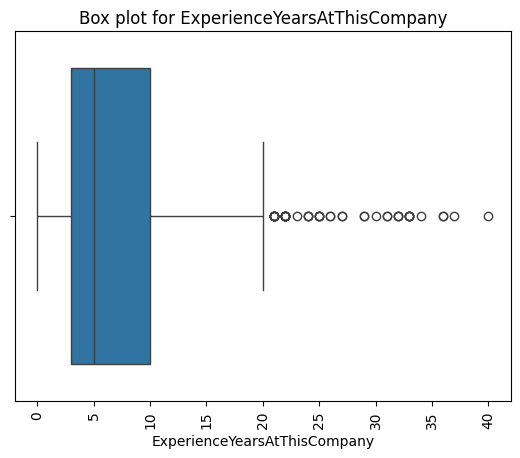

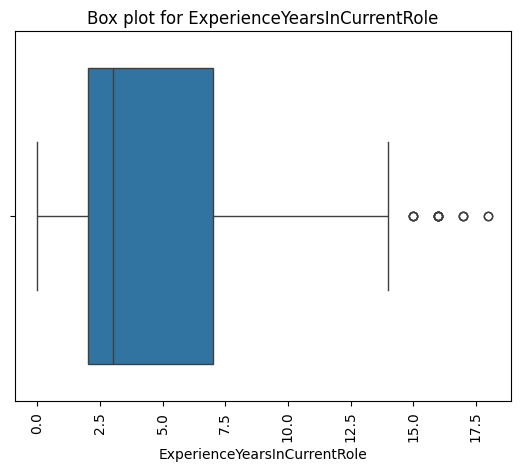

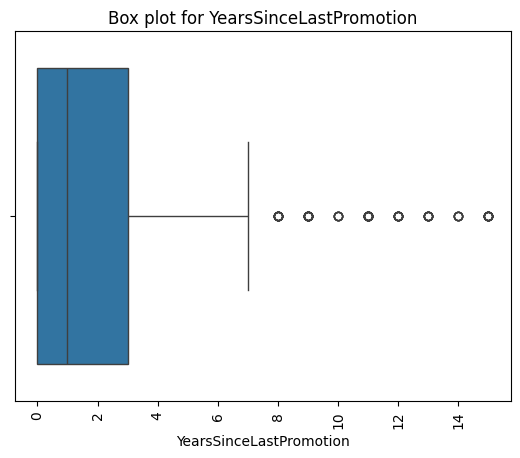

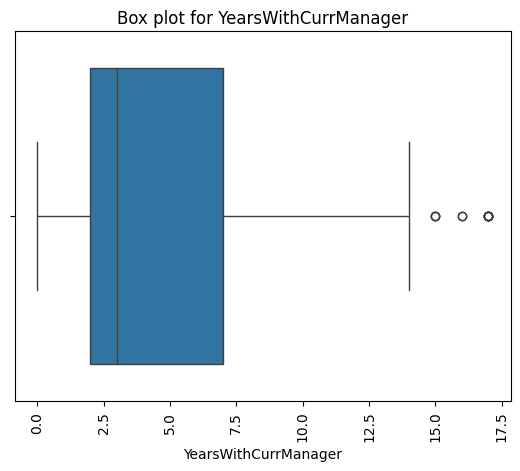

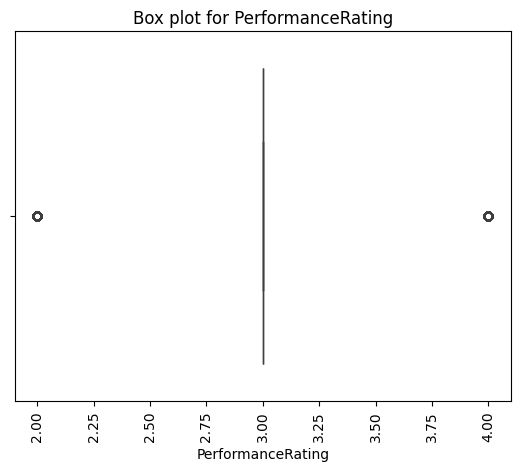

In [163]:
plt.figure(figsize=(15,10))
for col in num:
    sns.boxplot(x=data[col])
    plt.xticks(rotation=90)
    plt.title(f"Box plot for {col}")
    plt.show()

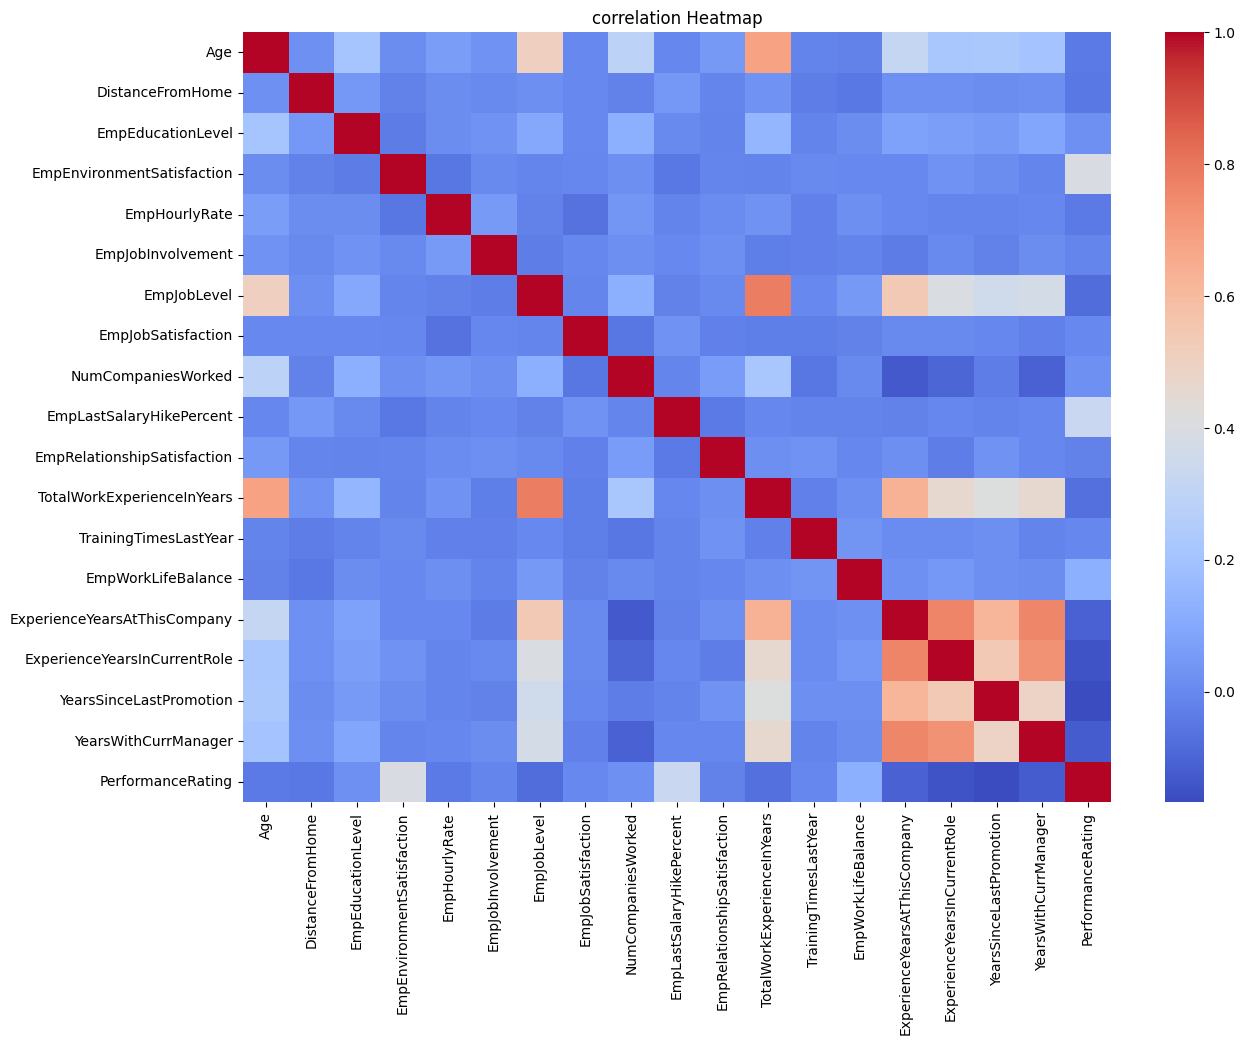

In [164]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('correlation Heatmap')
plt.show()

In [165]:
corr["PerformanceRating"].sort_values(ascending=False)

PerformanceRating               1.000000
EmpEnvironmentSatisfaction      0.395561
EmpLastSalaryHikePercent        0.333722
EmpWorkLifeBalance              0.124429
NumCompaniesWorked              0.020980
EmpEducationLevel               0.020529
EmpJobSatisfaction              0.000606
TrainingTimesLastYear          -0.005443
EmpJobInvolvement              -0.010539
EmpRelationshipSatisfaction    -0.019502
Age                            -0.040164
EmpHourlyRate                  -0.043116
DistanceFromHome               -0.046142
TotalWorkExperienceInYears     -0.068141
EmpJobLevel                    -0.076632
ExperienceYearsAtThisCompany   -0.111645
YearsWithCurrManager           -0.122313
ExperienceYearsInCurrentRole   -0.147638
YearsSinceLastPromotion        -0.167629
Name: PerformanceRating, dtype: float64

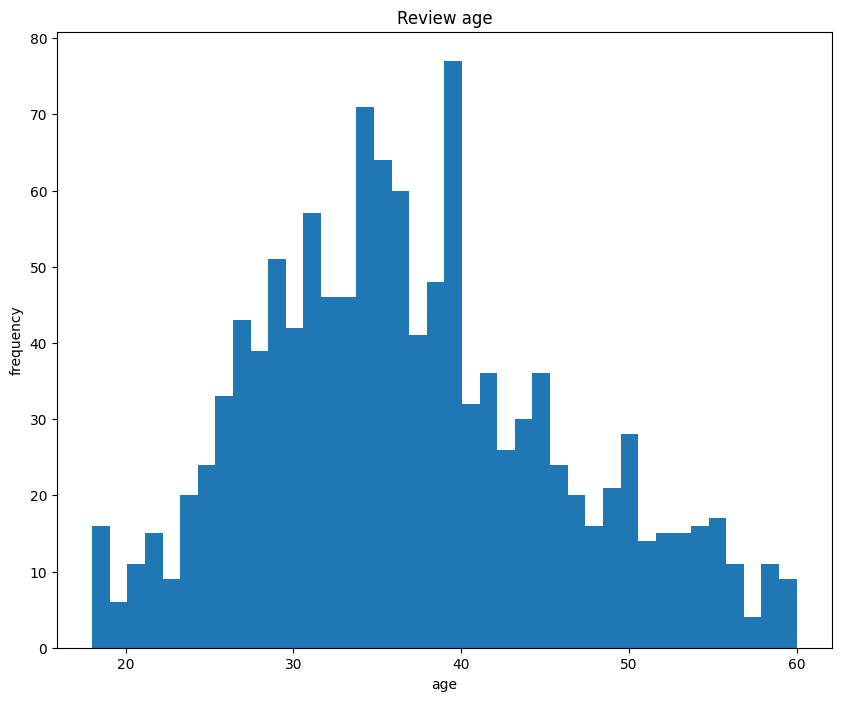

In [166]:
plt.figure(figsize=(10,8))
plt.hist(x=data['Age'], bins=40)
plt.xlabel('age')
plt.ylabel('frequency')
plt.title('Review age')
plt.show()

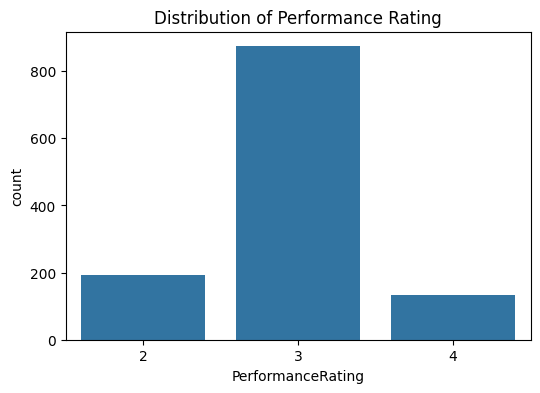

In [167]:
plt.figure(figsize=(6,4))
sns.countplot(x="PerformanceRating", data=data)
plt.title("Distribution of Performance Rating")
plt.show()

In [168]:
dept_perf = data.groupby("EmpDepartment")["PerformanceRating"].mean().sort_values(ascending=False)
dept_perf

EmpDepartment
Development               3.085873
Data Science              3.050000
Human Resources           2.925926
Research & Development    2.921283
Sales                     2.860590
Finance                   2.775510
Name: PerformanceRating, dtype: float64

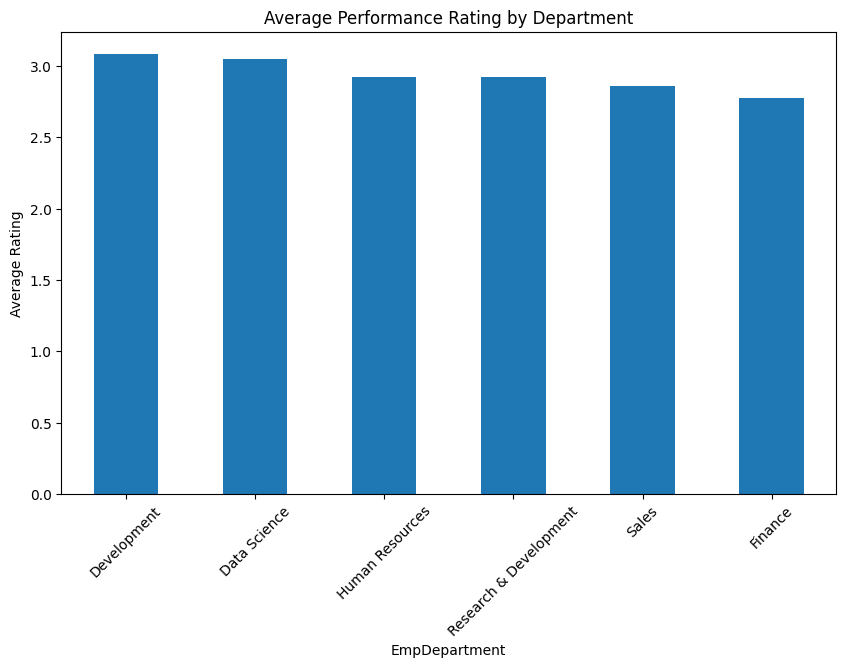

In [169]:
plt.figure(figsize=(10,6))
dept_perf.plot(kind="bar")
plt.title("Average Performance Rating by Department")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

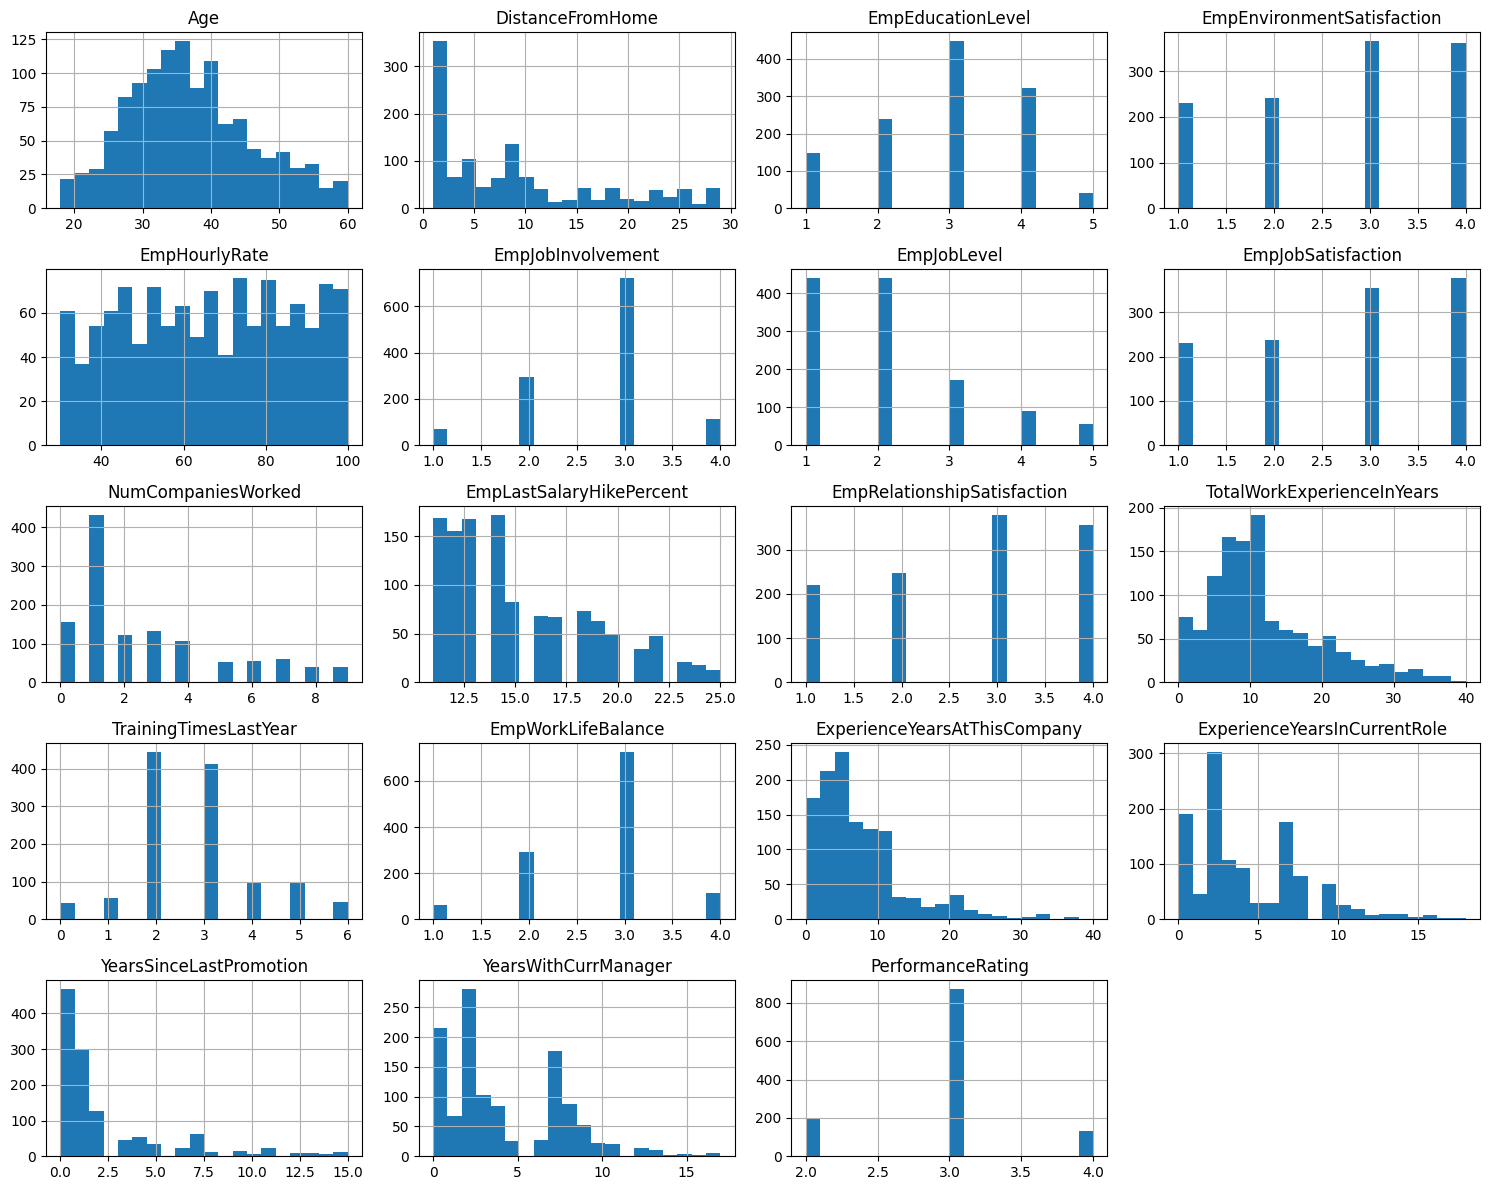

In [170]:
num_cols = data.select_dtypes(include=np.number).columns

data[num_cols].hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

# Feature Engineering

In [171]:
data.Age.skew()

np.float64(0.38414495910435587)

In [172]:
data.PerformanceRating.value_counts()

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

In [173]:
for col in num:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    outliers = data[(data[col] < lower ) | (data[col] > upper)]
    #print(col, "outliers :", outliers.shape[0])
    print(col)
    data['outlier_flag'] = ((data[col] < lower) | (data[col] > upper)).astype(int)
    print(data.groupby('outlier_flag')['PerformanceRating'].value_counts(normalize=True))

Age
outlier_flag  PerformanceRating
0             3                    0.728333
              2                    0.161667
              4                    0.110000
Name: proportion, dtype: float64
DistanceFromHome
outlier_flag  PerformanceRating
0             3                    0.728333
              2                    0.161667
              4                    0.110000
Name: proportion, dtype: float64
EmpEducationLevel
outlier_flag  PerformanceRating
0             3                    0.728333
              2                    0.161667
              4                    0.110000
Name: proportion, dtype: float64
EmpEnvironmentSatisfaction
outlier_flag  PerformanceRating
0             3                    0.728333
              2                    0.161667
              4                    0.110000
Name: proportion, dtype: float64
EmpHourlyRate
outlier_flag  PerformanceRating
0             3                    0.728333
              2                    0.161667
            

In [174]:
data['outlier_flag']

0       0
1       0
2       1
3       0
4       0
       ..
1195    1
1196    0
1197    0
1198    0
1199    1
Name: outlier_flag, Length: 1200, dtype: int64

In [175]:
data = data.drop(columns='outlier_flag')

In [176]:
num = num.drop(columns='PerformanceRating')

In [177]:
num

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,32,10,3,4,55,3,2,4,1,12,4,10,2,2,10,7,0,8
1,47,14,4,4,42,3,2,1,2,12,4,20,2,3,7,7,1,7
2,40,5,4,4,48,2,3,1,5,21,3,20,2,3,18,13,1,12
3,41,10,4,2,73,2,5,4,3,15,2,23,2,2,21,6,12,6
4,60,16,4,1,84,3,2,1,8,14,4,10,1,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,27,3,1,4,71,4,2,4,1,20,2,6,3,3,6,5,0,4
1196,37,10,2,4,80,4,1,4,3,17,1,4,2,3,1,0,0,0
1197,50,28,1,4,74,4,1,3,1,11,3,20,3,3,20,8,3,8
1198,34,9,3,4,46,2,3,2,1,14,2,9,3,4,8,7,7,7


In [178]:
outlier_columns = []
for col in num:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3-Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outlier = data[(data[col] < lower) | (data[col] > upper)]

    if len(outlier) > 0:
        outlier_columns.append(col)

print("columns with outlier")
print(outlier_columns)

columns with outlier
['NumCompaniesWorked', 'TotalWorkExperienceInYears', 'TrainingTimesLastYear', 'ExperienceYearsAtThisCompany', 'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [179]:
for col in outlier_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3-Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    data[col] = np.where(data[col] < lower, lower, np.where(data[col] > upper, upper, data[col]))

In [180]:
data.PerformanceRating.value_counts()

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

In [181]:
data

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10.0,2.0,2,10.0,7.0,0.0,8.0,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20.0,2.0,3,7.0,7.0,1.0,7.0,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20.0,2.0,3,18.0,13.0,1.0,12.0,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23.0,2.0,2,20.5,6.0,7.5,6.0,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10.0,1.0,3,2.0,2.0,2.0,2.0,No,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6.0,3.0,3,6.0,5.0,0.0,4.0,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4.0,2.0,3,1.0,0.0,0.0,0.0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20.0,3.0,3,20.0,8.0,3.0,8.0,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9.0,3.0,4,8.0,7.0,7.0,7.0,No,3


In [182]:
data = data.drop(columns='EmpNumber')

In [183]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           1200 non-null   int64  
 1   Gender                        1200 non-null   object 
 2   EducationBackground           1200 non-null   object 
 3   MaritalStatus                 1200 non-null   object 
 4   EmpDepartment                 1200 non-null   object 
 5   EmpJobRole                    1200 non-null   object 
 6   BusinessTravelFrequency       1200 non-null   object 
 7   DistanceFromHome              1200 non-null   int64  
 8   EmpEducationLevel             1200 non-null   int64  
 9   EmpEnvironmentSatisfaction    1200 non-null   int64  
 10  EmpHourlyRate                 1200 non-null   int64  
 11  EmpJobInvolvement             1200 non-null   int64  
 12  EmpJobLevel                   1200 non-null   int64  
 13  Emp

In [184]:
## use Label encoder

In [185]:
le = LabelEncoder()

use LabelEncoder to convert categorical values into numeric values

In [186]:
data[data.select_dtypes(include='object').columns] = data[data.select_dtypes(include='object').columns].apply(le.fit_transform) 

In [187]:
data

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,32,1,2,2,5,13,2,10,3,4,...,4,10.0,2.0,2,10.0,7.0,0.0,8.0,0,3
1,47,1,2,2,5,13,2,14,4,4,...,4,20.0,2.0,3,7.0,7.0,1.0,7.0,0,3
2,40,1,1,1,5,13,1,5,4,4,...,3,20.0,2.0,3,18.0,13.0,1.0,12.0,0,4
3,41,1,0,0,3,8,2,10,4,2,...,2,23.0,2.0,2,20.5,6.0,7.5,6.0,0,3
4,60,1,2,2,5,13,2,16,4,1,...,4,10.0,1.0,3,2.0,2.0,2.0,2.0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,27,0,3,0,5,13,1,3,1,4,...,2,6.0,3.0,3,6.0,5.0,0.0,4.0,0,4
1196,37,1,1,2,1,15,2,10,2,4,...,1,4.0,2.0,3,1.0,0.0,0.0,0.0,0,3
1197,50,1,3,1,1,15,2,28,1,4,...,3,20.0,3.0,3,20.0,8.0,3.0,8.0,0,3
1198,34,0,3,2,0,1,2,9,3,4,...,2,9.0,3.0,4,8.0,7.0,7.0,7.0,0,3


In [188]:
# Split Data into Train and Test

In [189]:
data_train, data_test = train_test_split(data, random_state=42, test_size=.3)

In [190]:
df1 = data_train[data_train.PerformanceRating==2]
df2 = data_train[data_train.PerformanceRating==4]

data_train = pd.concat([data_train,df1,df1,df1,df2,df2,df2,df2,df2])

In [191]:
data_train_x = data_train.iloc[:,:-1]
data_train_y = data_train.iloc[:,-1]

In [192]:
data_test_x = data_test.iloc[:,:-1]
data_test_y = data_test.iloc[:,-1]

In [193]:
 data_train.PerformanceRating.value_counts()

PerformanceRating
3    606
2    580
4    534
Name: count, dtype: int64

In [194]:
data_train.shape

(1720, 27)

In [195]:
# Logistic Regression

In [196]:
# Initialize Logistic Regression
LR = LogisticRegression(max_iter=1000, n_jobs=-1)

In [197]:
# Train the model
LR.fit(data_train_x, data_train_y)

LogisticRegression(max_iter=1000, n_jobs=-1)

In [198]:
# Predict on test data
LR_pred = LR.predict(data_test_x)

In [199]:
# Evaluate

In [200]:
print("accuracy=",accuracy_score(data_test_y, LR_pred))
print("classification report=\n",classification_report(data_test_y, LR_pred))
print("confusion_matrix=\n",confusion_matrix(data_test_y, LR_pred))

accuracy= 0.7138888888888889
classification report=
               precision    recall  f1-score   support

           2       0.43      0.71      0.54        49
           3       0.91      0.71      0.80       268
           4       0.46      0.74      0.57        43

    accuracy                           0.71       360
   macro avg       0.60      0.72      0.63       360
weighted avg       0.79      0.71      0.73       360

confusion_matrix=
 [[ 35  11   3]
 [ 43 190  35]
 [  3   8  32]]


"""
📊 LOGISTIC REGRESSION MODEL REPORT

--------------------------------------------------
Accuracy (71.39%)
--------------------------------------------------
The model correctly predicts 71.39% of employee performance ratings.
This serves as a baseline model for multi-class classification.

--------------------------------------------------
Confusion Matrix Analysis
--------------------------------------------------

[[ 35  11   3]
 [ 43 190  35]
 [  3   8  32]]

Key Observations:

- 43 average performers (class 3) misclassified as low performers
- 35 average performers misclassified as high performers
- Majority confusion occurs around class 3

The model struggles to clearly separate performance levels.

--------------------------------------------------
Verdict
--------------------------------------------------

Logistic Regression provides a reasonable baseline performance (71% accuracy),
but it lacks strong class separation.

Tree-based models are likely to perform better for this dataset.
"""


In [201]:
# Decision Tree

In [202]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=15)

In [203]:
dt.fit(data_train_x, data_train_y)

DecisionTreeClassifier(max_depth=15)

In [204]:
dt_pred = dt.predict(data_test_x)

In [205]:
print("accuracy=",accuracy_score(data_test_y, dt_pred))
print("classification report=\n",classification_report(data_test_y, dt_pred))
print("confusion_matrix=\n",confusion_matrix(data_test_y, dt_pred))

accuracy= 0.8916666666666667
classification report=
               precision    recall  f1-score   support

           2       0.76      0.80      0.78        49
           3       0.93      0.93      0.93       268
           4       0.81      0.79      0.80        43

    accuracy                           0.89       360
   macro avg       0.83      0.84      0.84       360
weighted avg       0.89      0.89      0.89       360

confusion_matrix=
 [[ 39  10   0]
 [ 12 248   8]
 [  0   9  34]]


"""
📊 DECISION TREE MODEL REPORT

--------------------------------------------------
Accuracy (87.78%)
--------------------------------------------------
The model correctly predicts 87.8% of employee performance ratings.
This is a strong improvement over Logistic Regression (71%).

--------------------------------------------------
Confusion Matrix Analysis
--------------------------------------------------

[[ 37  12   0]
 [ 15 248   5]
 [  1  11  31]]

Key Observations:

- Only 15 class-3 employees misclassified as class-2
- Only 5 class-3 employees misclassified as class-4
- Very small confusion between class-2 and class-4
- Majority of errors occur between adjacent performance levels

The model clearly separates low, average, and high performers much better than Logistic Regression.

--------------------------------------------------
Verdict
--------------------------------------------------

Decision Tree significantly outperforms Logistic Regression.
It provides strong classification accuracy and better class separation.

However, tree-based models may overfit.
Further validation with cross-validation or ensemble methods (Random Forest, XGBoost)
is recommended before final deployment.
"""


In [206]:
## Random Forest

In [207]:
# Initialize Random Forest
RF = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1)

In [208]:
# Train the model
RF.fit(data_train_x,data_train_y)

RandomForestClassifier(max_depth=15, n_jobs=-1)

In [209]:
# Predict on test data
RF_pred = RF.predict(data_test_x)

In [210]:
# Evaluate
print("accuracy=",accuracy_score(data_test_y, RF_pred))

print("classification report=\n",classification_report(data_test_y, RF_pred))
print("confusion_matrix=\n",confusion_matrix(data_test_y, RF_pred))

accuracy= 0.9194444444444444
classification report=
               precision    recall  f1-score   support

           2       0.84      0.88      0.86        49
           3       0.93      0.96      0.95       268
           4       0.94      0.70      0.80        43

    accuracy                           0.92       360
   macro avg       0.90      0.85      0.87       360
weighted avg       0.92      0.92      0.92       360

confusion_matrix=
 [[ 43   6   0]
 [  8 258   2]
 [  0  13  30]]


"""
📊 RANDOM FOREST MODEL REPORT

--------------------------------------------------
Accuracy (91.39%)
--------------------------------------------------
The model correctly predicts 91.39% of employee performance ratings.
This is the highest accuracy achieved among all tested models.

--------------------------------------------------
Confusion Matrix Analysis
--------------------------------------------------

[[ 43   6   0]
 [ 10 255   3]
 [  0  12  31]]

Key Observations:

- Only 6 low performers misclassified as average
- Only 10 average performers misclassified as low
- Minimal confusion between extreme classes (2 and 4)
- Most errors occur between adjacent performance levels

The model clearly separates performance categories
with significantly reduced misclassification compared to Logistic Regression and Decision Tree.

Verdict
--------------------------------------------------

Random Forest outperforms Logistic Regression and Decision Tree.

It provides high accuracy, balanced class performance,
and reduced overfitting risk compared to a single tree.

This model is recommended as the final production model
for predicting employee performance.
"""


# MODEL COMPARISON REPORT

In [139]:
# Create a summary table
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree", "Random Forest"],
    "Accuracy": [0.72, 0.88, 0.91],
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.72
1,Decision Tree,0.88
2,Random Forest,0.91


### 🔎 TOP 3 FACTORS – JUSTIFICATION

1️⃣ Total Work Experience:
Employees with higher overall experience tend to perform better
due to accumulated skills and organizational familiarity.

2️⃣ Years Since Last Promotion:
Long gaps in promotion correlate with lower performance,
possibly due to reduced motivation and career stagnation.

3️⃣ Job Satisfaction:
Higher satisfaction levels strongly associate with higher performance ratings,
indicating morale directly impacts productivity.

These factors were consistently ranked high in feature importance analysis
and align logically with HR performance theories.

# 📊 PREDICTIVE MODELING REPORT

1️⃣ Objective

The goal of this project is to predict employee performance ratings
(Low, Average, High) using HR-related factors.

The prediction helps management:
- Identify low performers early
- Recognize high-performing employees
- Understand key drivers influencing performance
- Make data-driven HR decisions without harming employee morale

--------------------------------------------------

2️⃣ Models Used

Three classification models were implemented:

Logistic Regression:
Baseline model; simple and interpretable.

Decision Tree:
Captures non-linear relationships; better class separation.

Random Forest:
Ensemble model; reduces overfitting and improves prediction accuracy.

--------------------------------------------------

3️⃣ Evaluation Metrics

Accuracy → Overall percentage of correct predictions.

Precision → Reliability of predicted class.

Recall → Ability to correctly identify actual class.

F1-score → Balance between precision and recall.

Confusion Matrix → Detailed misclassification breakdown.

--------------------------------------------------

4️⃣ Model Performance Comparison

Logistic Regression
Accuracy: 0.71
Weak class separation, especially around average performers.

Decision Tree
Accuracy: 0.88
Strong improvement, better class-level performance.

Random Forest
Accuracy: 0.91
Highest accuracy and best balance across all classes.

✅ Suggestion:

Random Forest is the best-performing model.
It provides strong precision and recall across all performance categories
and minimizes misclassification between extreme classes.

--------------------------------------------------

5️⃣ Top Factors Influencing Employee Performance

Based on tree-based feature importance analysis,
the most influential factors include:

- Total Work Experience
- Experience in Current Role
- Years Since Last Promotion
- Job Satisfaction
- Environment Satisfaction
- Training Times Last Year
- Work-Life Balance

Interpretation:

Employees with:
- Higher experience
- Recent promotions
- Higher satisfaction levels
- Better work-life balance

→ Tend to receive higher performance ratings.

Employees with:
- Limited experience
- Longer promotion gaps
- Lower satisfaction levels

→ More likely to receive lower ratings.

--------------------------------------------------

6️⃣ Challenges Faced and Solutions

Challenge: Outliers in experience-related features
Solution: Applied IQR-based capping to stabilize extreme values.

Challenge: Multi-class target labels (2, 3, 4)
Solution: Encoded labels properly for tree-based models.

Challenge: Slight class imbalance
Solution: Evaluated using macro and weighted metrics.

Challenge: Risk of overfitting in Decision Tree
Solution: Used Random Forest for better generalization.

--------------------------------------------------

7️⃣ Conclusion

Random Forest is recommended for deployment
to predict employee performance accurately.

The analysis identified clear performance drivers,
allowing management to:

- Improve training strategies
- Reduce promotion delays
- Enhance employee satisfaction
- Strengthen retention policies

The workflow includes:
Data Cleaning → Feature Engineering → Model Training →
Evaluation → Business Insights

This project provides actionable, data-backed insights
for improving overall employee performance.
"""


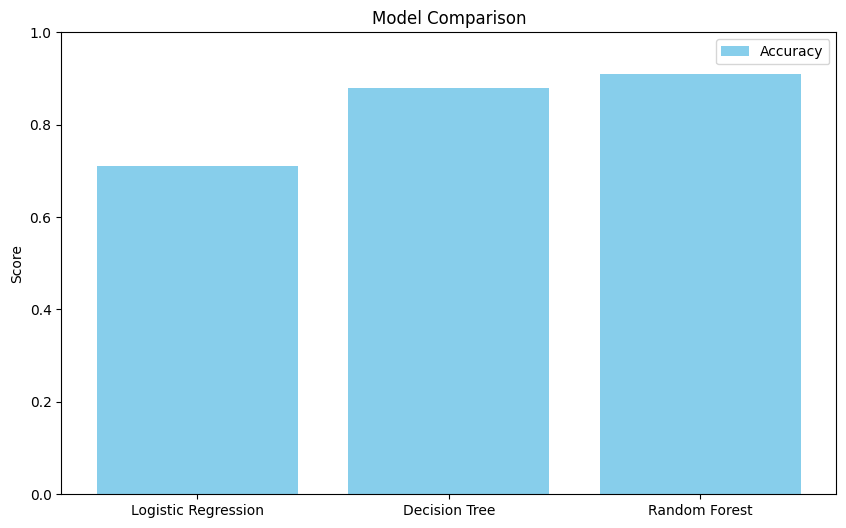

In [141]:
# Model names and metrics
models = ["Logistic Regression","Decision Tree", "Random Forest"]
accuracy = [0.71, 0.88, 0.91]

plt.figure(figsize=(10,6))
# Accuracy
plt.bar(models, accuracy, color='skyblue', label='Accuracy')
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend()
plt.show()


### 📊 MODEL PERFORMANCE COMPARISON

- Logistic Regression served as the baseline model with 71% accuracy,
showing moderate performance but weaker class separation.

- Decision Tree improved accuracy to 88%, providing better distinction
between performance levels.

- Random Forest achieved the highest accuracy at 91%,
with strong precision and recall across all classes.

- Therefore, Random Forest is the most suitable model for predicting
employee performance in this project due to its superior accuracy
and balanced performance.


### 📈 STRATEGIC RECOMMENDATIONS

1️⃣ Reduce Promotion Gaps:
Implement structured promotion cycles and performance reviews
to prevent long stagnation periods.

2️⃣ Enhance Training Programs:
Increase training frequency in underperforming departments
to improve skill development and engagement.

3️⃣ Improve Work Environment:
Monitor job and environment satisfaction metrics regularly
to identify morale issues early.

4️⃣ Targeted Intervention:
Use the Random Forest model to proactively identify at-risk employees
and provide mentorship or development programs.

5️⃣ Data-Driven HR Strategy:
Adopt predictive analytics as part of performance management
to maintain high service delivery standards.